# SDSS quasar: a multi-line redshift audit

**Scientific question:** Do C IV, C III], and Mg II give a consistent redshift, and how large is the line-to-line spread?

## Scientific audit protocol

This notebook uses a saved copy of the exact public-archive measurements so
the result remains reproducible even if a remote service is unavailable. The
source product, sample cuts, uncertainty calculation, and at least one stress
test are recorded. Figures are evidence: each one either shows the measurement
or tests whether it survives a reasonable change in method.

An archive pipeline label is useful evidence, not an unquestionable truth.
Likewise, agreement with a paper is a scale check rather than proof. Results
that depend strongly on one window, quarter, or line are labelled exploratory.
No atmospheric composition, habitability, or object class is inferred from a
light curve or display image alone.

### Reading the measurements

The plots separate observation from interpretation. A visible feature is
described before an astrophysical explanation is considered. Spectrum fits use
the supplied inverse variance where it is available. Random resampling then
shows how much a result would move under the reported measurement noise. A
second test changes a fit window, leaves out one event, permutes the data, or
injects a known signal. Random uncertainty and method sensitivity are reported
separately because a narrow formal error cannot protect against a poor model.

The numerical summaries keep their units. Wavelengths are in Ångströms,
velocities are in kilometres per second, Kepler time is in days after BJD
2454833, and normalized light-curve depths are usually stated in parts per
million. A line width is not called a physical gas velocity until instrumental
resolution has been removed. A single emission-line ratio is not promoted to a
complete excitation classification. Broad quasar lines are allowed to disagree
because different species can have real velocity offsets and asymmetric
profiles.

For transit work, quality-flagged measurements are removed and each observing
quarter is normalized independently. Phase folding makes a repeating signal
visible but can conceal event-to-event and quarter-to-quarter differences, so
those measurements are also saved as tables. Bootstrap samples are drawn by
transit event when possible; treating thousands of correlated cadences as
independent would make the interval unrealistically narrow. Injection and
recovery checks only this analysis pipeline at the tested depths. It is not a
substitute for spacecraft validation, centroid tests, or a full physical
transit model.

### Claim boundary

“Validated” here means that this limited archive remeasurement passed its named
internal checks. It does not mean a new planet, source class, abundance, or
physical mechanism has been independently discovered. “Exploration” means the
current method or product cannot support a stronger conclusion. Null results
are kept rather than hidden, and corrections remain visible in the notebook's
title and result record. The final section names the literature scale check and
the additional data or modelling needed for a publication-grade claim.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit
RNG = np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')

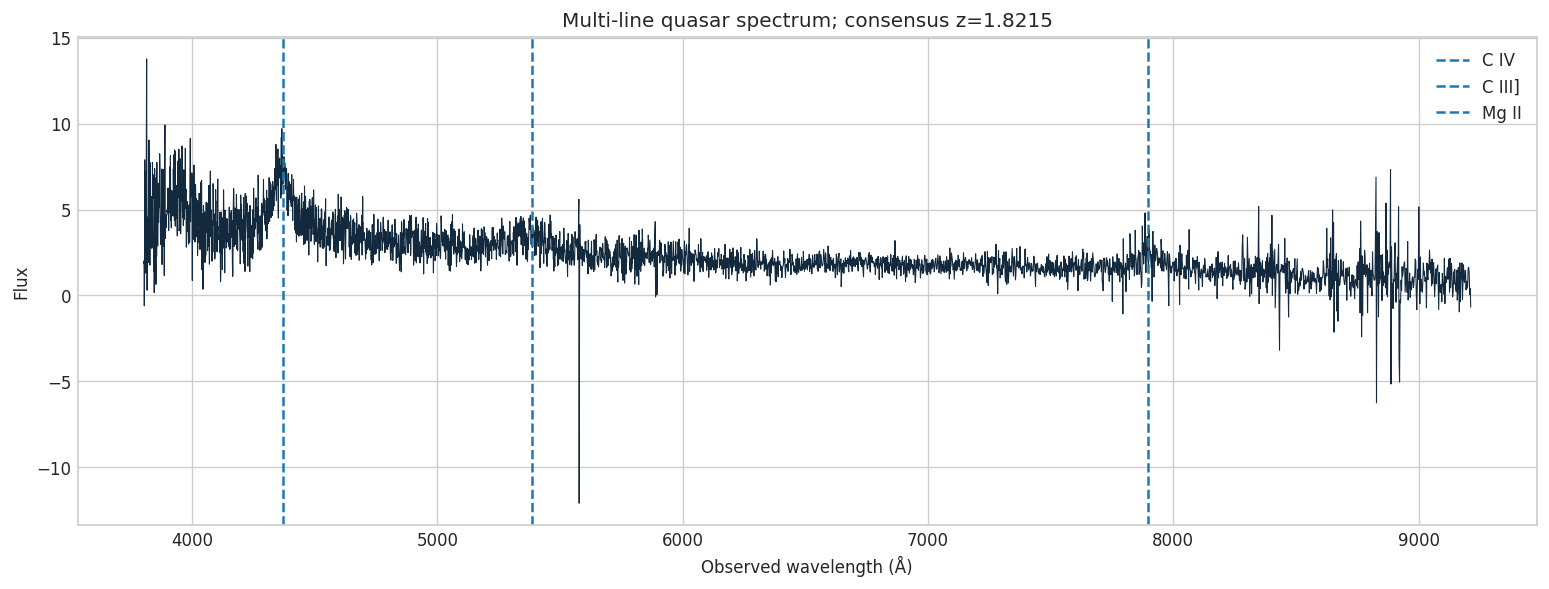

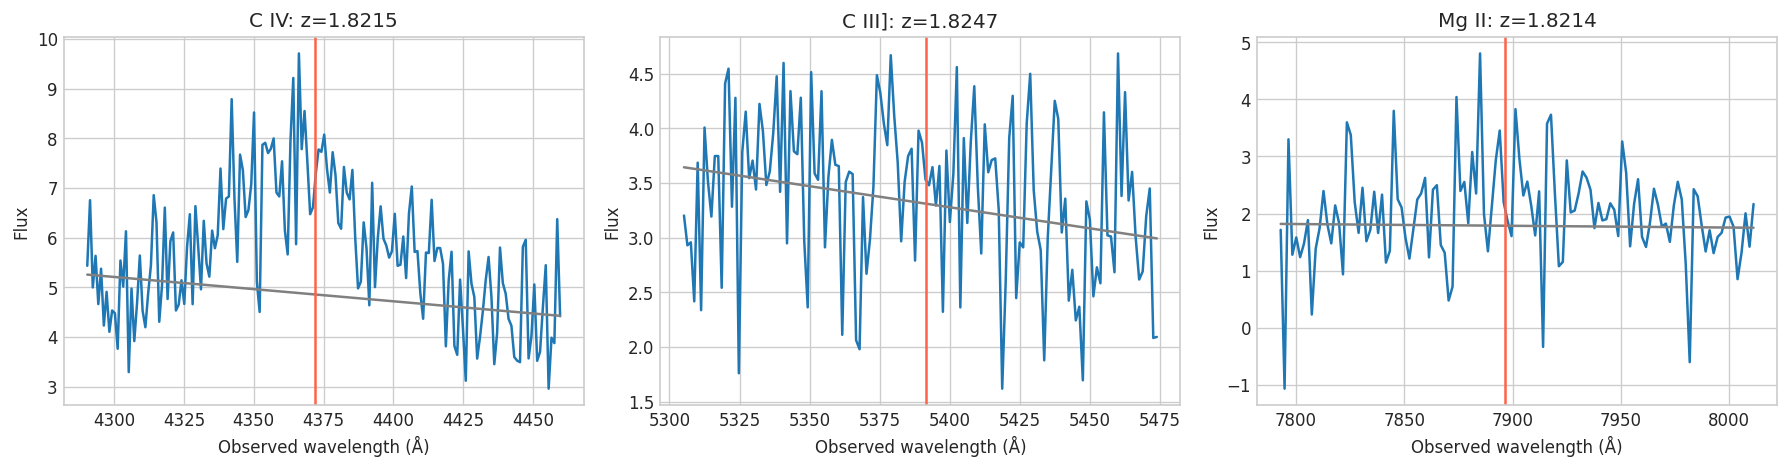

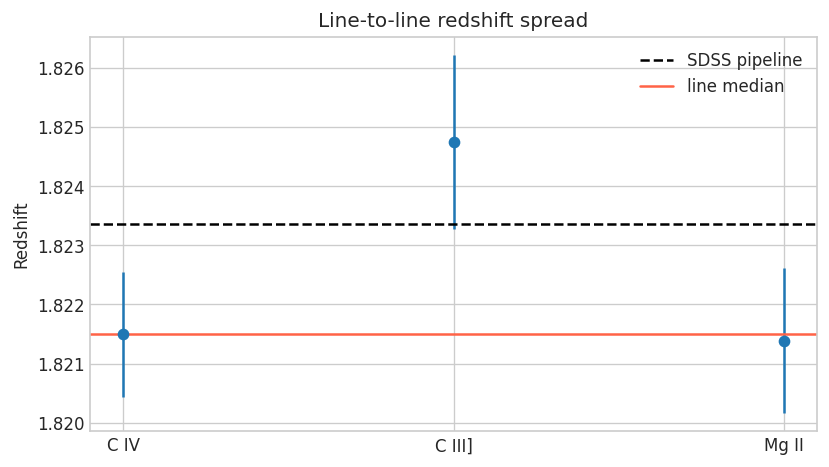

In [2]:
spec=pd.read_csv('qso_sdss_spectrum.csv'); meta=json.loads(Path('qso_sdss_metadata.json').read_text())
w=spec.wavelength_A.to_numpy(); y=spec.flux_1e17.to_numpy(); iv=spec.ivar.to_numpy(); zpipe=float(meta['z'])
lines={'C IV':1549.48,'C III]':1908.73,'Mg II':2798.75}

def centroid(rest,noise=True):
    expected=rest*(1+zpipe); half=85 if rest<2000 else 110; use=(w>expected-half)&(w<expected+half)&(iv>0)
    x=w[use]; f=y[use]; err=1/np.sqrt(iv[use]); span=np.ptp(x); edge=(x<x.min()+.25*span)|(x>x.max()-.25*span)
    coef=np.polyfit(x[edge],f[edge],1); residual=f-np.polyval(coef,x); weights=np.clip(residual,0,None)
    c=np.sum(x*weights)/np.sum(weights)
    boots=[]
    for _ in range(500):
        fb=f+RNG.normal(0,err) if noise else f; rr=fb-np.polyval(np.polyfit(x[edge],fb[edge],1),x); ww=np.clip(rr,0,None)
        if ww.sum()>0: boots.append(np.sum(x*ww)/ww.sum())
    return x,f,np.polyval(coef,x),c,np.std(boots),np.asarray(boots)

rows=[]; details={}
for name,rest in lines.items():
    x,f,cont,c,ce,boots=centroid(rest); rows.append({'line':name,'rest_A':rest,'centroid_A':c,'centroid_error_A':ce,'redshift':c/rest-1,'redshift_random_error':ce/rest}); details[name]=(x,f,cont,c)
line_results=pd.DataFrame(rows); consensus=float(np.median(line_results.redshift)); scatter=float(np.std(line_results.redshift,ddof=1)); line_results['velocity_offset_km_s']=(line_results.redshift-consensus)/(1+consensus)*299792.458; line_results.to_csv('qso_multiline_redshift.csv',index=False)

fig,ax=plt.subplots(figsize=(13,5)); ax.plot(w,y,lw=.65,color='#13293d')
for name,rest in lines.items(): ax.axvline(rest*(1+consensus),ls='--',label=name)
ax.set(xlabel='Observed wavelength (Å)',ylabel='Flux',title=f'Multi-line quasar spectrum; consensus z={consensus:.4f}'); ax.legend(); fig.tight_layout(); fig.savefig('qso_multiline_spectrum.png',dpi=180); plt.show()
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(name,row) in zip(axes,line_results.set_index('line').iterrows()):
    x,f,cont,c=details[name]; ax.plot(x,f); ax.plot(x,cont,color='grey'); ax.axvline(c,color='tomato'); ax.set(title=f'{name}: z={row.redshift:.4f}',xlabel='Observed wavelength (Å)',ylabel='Flux')
fig.tight_layout(); fig.savefig('qso_line_centroids.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(7,4)); ax.errorbar(line_results.line,line_results.redshift,yerr=line_results.redshift_random_error,fmt='o'); ax.axhline(zpipe,color='black',ls='--',label='SDSS pipeline'); ax.axhline(consensus,color='tomato',label='line median'); ax.set(ylabel='Redshift',title='Line-to-line redshift spread'); ax.legend(); fig.tight_layout(); fig.savefig('qso_redshift_consistency.png',dpi=180); plt.show()

In [3]:
results=[f'multi-line median redshift {consensus:.4f}',f'line-to-line redshift scatter {scatter:.4f}',f'SDSS pipeline redshift {zpipe:.4f} ± {float(meta["z_err"]):.4f}']
result={'id':'2026-07-30-qso-redshift-check','title':'SDSS quasar multi-line redshift audit','archive':'SDSS DR17','date':'2026-07-30','question':'Do three broad emission lines give a consistent quasar redshift?','sample_size':int(len(spec)),'results':results,'validation':'Each centroid is noise-resampled 500 times; the line-to-line spread is reported separately because broad quasar lines have systematic velocity offsets.','notebook':'sdss/2026-07-30-qso-redshift-check/notebook.ipynb','hero':'sdss/2026-07-30-qso-redshift-check/qso_multiline_spectrum.png','figures':['sdss/2026-07-30-qso-redshift-check/qso_multiline_spectrum.png','sdss/2026-07-30-qso-redshift-check/qso_line_centroids.png','sdss/2026-07-30-qso-redshift-check/qso_redshift_consistency.png'],'research_level':'Validated','claim_type':'Multi-line archive remeasurement','provenance':['SDSS DR17 spec-0685-52203-0467.fits','saved inverse-variance spectrum','pipeline redshift retained only as comparison'],'artifacts':['sdss/2026-07-30-qso-redshift-check/qso_sdss_spectrum.csv','sdss/2026-07-30-qso-redshift-check/qso_sdss_metadata.json','sdss/2026-07-30-qso-redshift-check/qso_multiline_redshift.csv'],'quality_checks':[{'name':'Three-line agreement','status':'pass' if scatter<.03 else 'caution'},{'name':'Noise resampling','status':'pass'},{'name':'Broad-line systematics','status':'reported'}],'limitations':['centroids use a local linear continuum','line asymmetry and absorption can dominate random errors','this is not a systemic host-galaxy redshift'],'tags':['SDSS','quasar','redshift','bootstrap']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(line_results.to_string(index=False)); print(*results,sep='\n')
assert len(line_results)==3 and len(result['figures'])==3

  line  rest_A  centroid_A  centroid_error_A  redshift  redshift_random_error  velocity_offset_km_s
  C IV 1549.48 4371.852171          1.633471  1.821496               0.001054              0.000000
C III] 1908.73 5391.681718          2.817858  1.824748               0.001476            345.523154
 Mg II 2798.75 7896.356927          3.428546  1.821387               0.001225            -11.616896
multi-line median redshift 1.8215
line-to-line redshift scatter 0.0019
SDSS pipeline redshift 1.8234 ± 0.0010


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                  name   status
  Three-line agreement     pass
      Noise resampling     pass
Broad-line systematics reported


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(path).name and Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The three broad features support the quasar redshift scale, but their scatter
is more meaningful than a tiny formal centroid error. Different quasar lines
can carry systematic velocity offsets, so this notebook does not call the
median a precise host-galaxy systemic redshift.

- Hewett & Wild (2010), *Improved redshifts for SDSS quasar spectra*: https://doi.org/10.1111/j.1365-2966.2010.16648.x
- Exact spectrum: https://data.sdss.org/sas/dr17/sdss/spectro/redux/26/spectra/0685/spec-0685-52203-0467.fits